# Masoor Price Prediction

In [2]:
!pip install pandas numpy matplotlib scikit-learn

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)


In [3]:
import pandas as pd

  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using c

In [4]:
df=pd.read_csv("masoor.csv")

In [5]:
df.head()

,City,Date,Crop,Price
0,AhmadPurEast,2008-04-01,Masoor Pulse(local),7000
1,AhmadPurEast,2008-04-01,Masoor Whole (Imported),0
2,AhmadPurEast,2008-04-01,Masoor Whole(local),0
3,AhmadPurEast,2008-04-01,Masoor Pulse (Imported),0
4,AhmadPurEast,2008-04-02,Masoor Pulse(local),7000


In [6]:
# Let Check which Cities are there in the Dataset , and then pick one
df['City'].unique()


array(['AhmadPurEast', 'Okara', 'Eminabad', 'Badomalhi', 'Basirpur',
       'Burewala', 'Bhakhar', 'Bhalwal', 'BahawalPur', 'BahawalNagar',
       'PakPattan', 'Piplan', 'Patoki', 'Pinanwal', 'PhoolNagar',
       'PirMahal', 'Tandlianwala', 'TALAGANG', 'Taunsasharif',
       'JalalPurJattan', 'Jauharabad', 'Jaranwala', 'Jhang', 'Jahanian',
       'Jhelum', 'Chistian', 'ChackJhumra', 'Chakwal', 'Chiniot',
       'ChuaSaidanShah', 'Chunian', 'Chichawatni', 'Hafizabad',
       'HujraShahmuqeem', 'Hasanabdal', 'Hazro', 'Khanpur', 'Khanewal',
       'Khushab', 'DunyaPur', 'Depalpur', 'RajanPur', 'Rawalpindi',
       'Raiwind', 'RahimYarKhan', 'RenalaKhurd', 'Sanglahill', 'Sahiwal',
       'Sraialamgir', 'Sargodha', 'Sillanwali', 'Sambrial', 'Summandri',
       'Sialkot', 'Shahjewana', 'ShujaAbad', 'Shakargarh', 'Shorkot',
       'Sheikhupura', 'SadiqAbad', 'ArifWala', 'Abdulhakim',
       'AliPurChatta', 'Farooqabad', 'Fatehpur', 'Fortabas', 'Faisalabad',
       'Quaidabad', 'Qadirpurrawan'

In [7]:
# Lets Pick Lahore
df_lahore = df[df['City'] == 'Lahore']

df_lahore.head()

,City,Date,Crop,Price
363520,Lahore,2008-04-07,Masoor Pulse(local),0
363521,Lahore,2008-04-07,Masoor Whole (Imported),0
363522,Lahore,2008-04-07,Masoor Whole(local),0
363523,Lahore,2008-04-07,Masoor Pulse (Imported),7750
363524,Lahore,2008-04-15,Masoor Pulse(local),0


In [8]:
df_lahore.shape

(17236, 4)

In [10]:
# There are two types of Crops  imported and local , we will go for local

df_lahore_local = df_lahore[df_lahore['Crop'] == 'Masoor Pulse(local)']
df_lahore_local.tail()

,City,Date,Crop,Price
380736,Lahore,2022-09-26,Masoor Pulse(local),27000
380740,Lahore,2022-09-27,Masoor Pulse(local),27000
380744,Lahore,2022-09-28,Masoor Pulse(local),27000
380748,Lahore,2022-09-29,Masoor Pulse(local),27000
380752,Lahore,2022-09-30,Masoor Pulse(local),27000


In [11]:
!pip install prophet


  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.1 MB 5.5 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.1 MB 6.9 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/12.1 MB 5.6 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/12.1 MB 6.5 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 6.8 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/12.1 MB 7.2 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 7.5 MB/s  0:00:01
   ---------------------------------------- 0

In [20]:
# Convert Date to datetime
df_lahore_local["Date"] = pd.to_datetime(df_lahore_local["Date"])


C:\Users\786\AppData\Local\Temp\ipykernel_14608\1508032983.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lahore_local["Date"] = pd.to_datetime(df_lahore_local["Date"])


In [21]:
# Prophet requires these column names
df_prophet = df_lahore_local.rename(columns={
    "Date": "ds",
    "Price": "y"
})


In [ ]:
# Sort by date
df_prophet = df_prophet.sort_values("ds")

print(df_prophet.tail())



          City         ds                 Crop      y
367864  Lahore 2022-12-27  Masoor Pulse(local)  22000
367868  Lahore 2022-12-28  Masoor Pulse(local)  22000
367872  Lahore 2022-12-29  Masoor Pulse(local)  22000
367876  Lahore 2022-12-30  Masoor Pulse(local)  22000
367880  Lahore 2022-12-31  Masoor Pulse(local)  22000


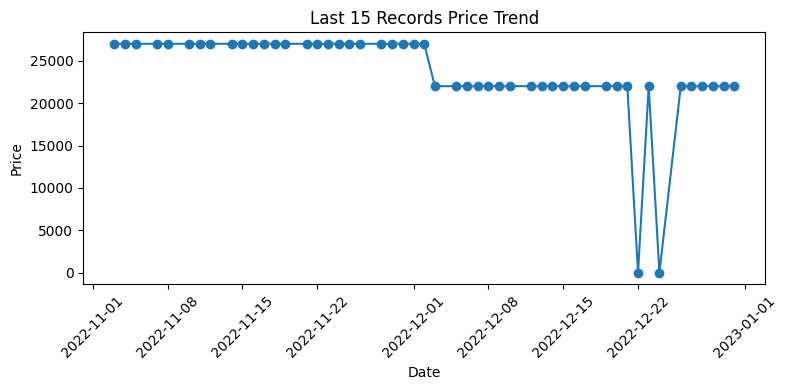

In [29]:
import matplotlib.pyplot as plt
# Take last 15 records
last_15 = df_prophet.tail(50)

# Line plot
plt.figure(figsize=(8,4))
plt.plot(last_15["ds"], last_15["y"], marker='o')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Last 15 Records Price Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(df_prophet)


22:43:47 - cmdstanpy - INFO - Chain [1] start processing
22:43:51 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)

# Show predictions
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7)

,ds,yhat,yhat_lower,yhat_upper
4309,2023-01-01,26381.312842,23518.664197,29286.689078
4310,2023-01-02,26139.768680,23049.967132,28821.231438
4311,2023-01-03,26164.279356,23219.672206,29176.403871
4312,2023-01-04,26282.865613,23410.241790,28984.504490
4313,2023-01-05,26198.496619,23271.400144,29097.045004
4314,2023-01-06,26322.661173,23562.333634,29313.676004
4315,2023-01-07,26294.005746,23509.393459,29284.841558


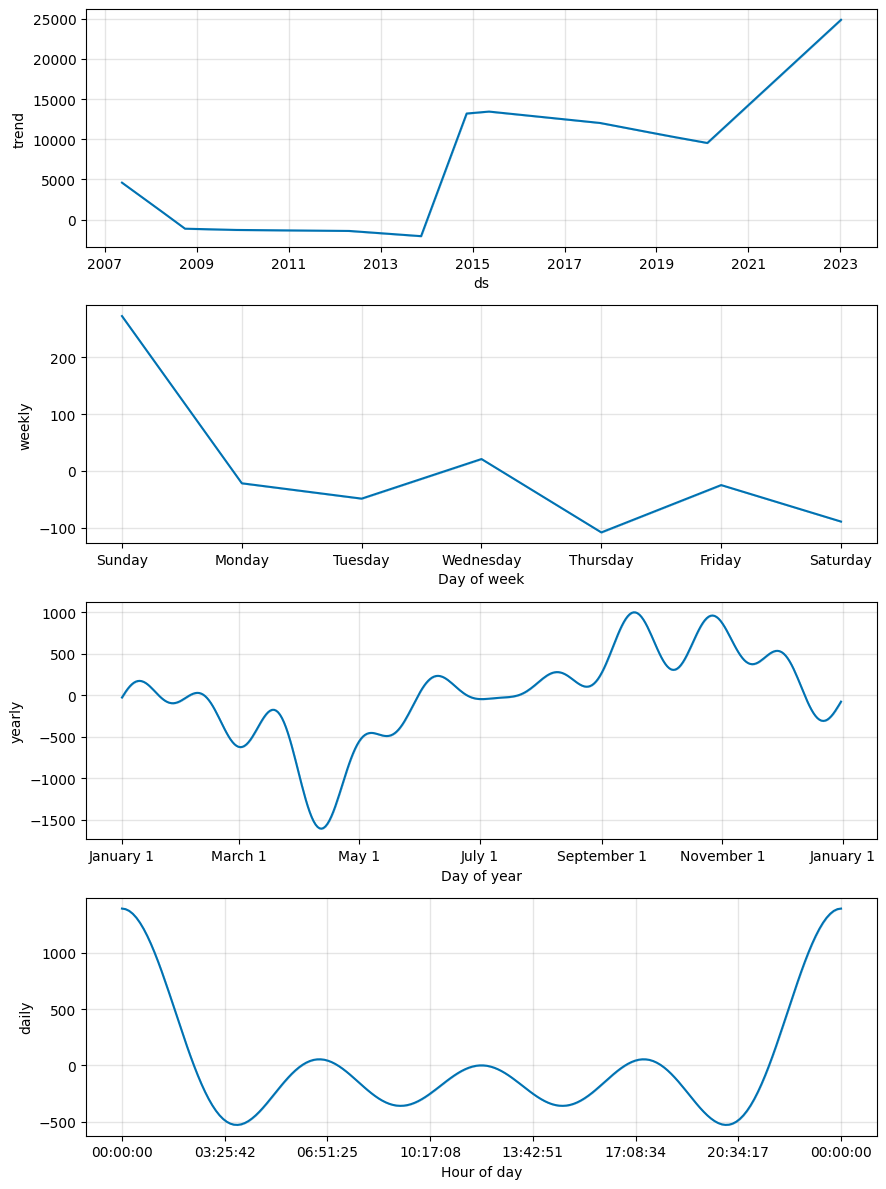

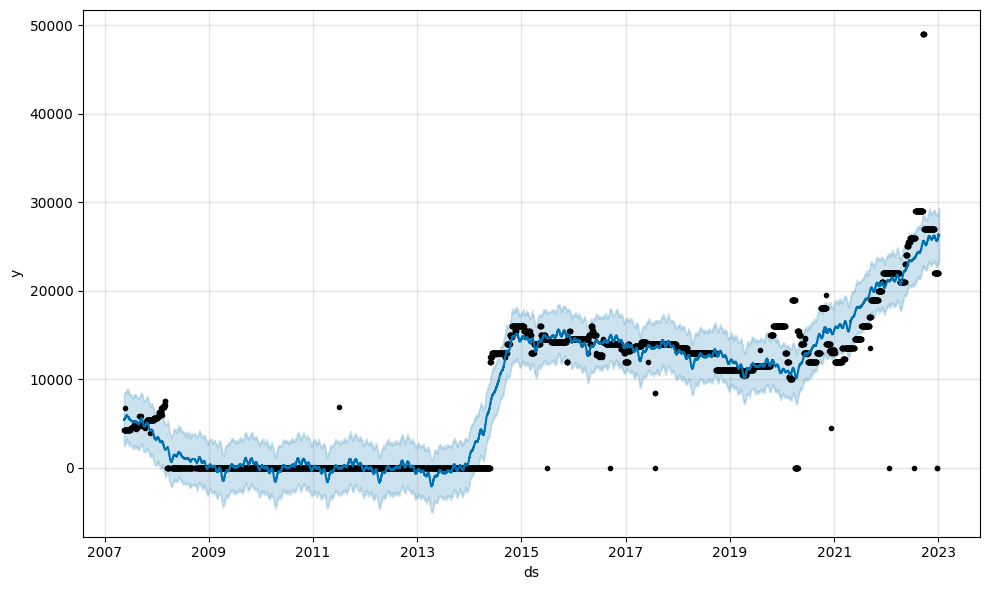

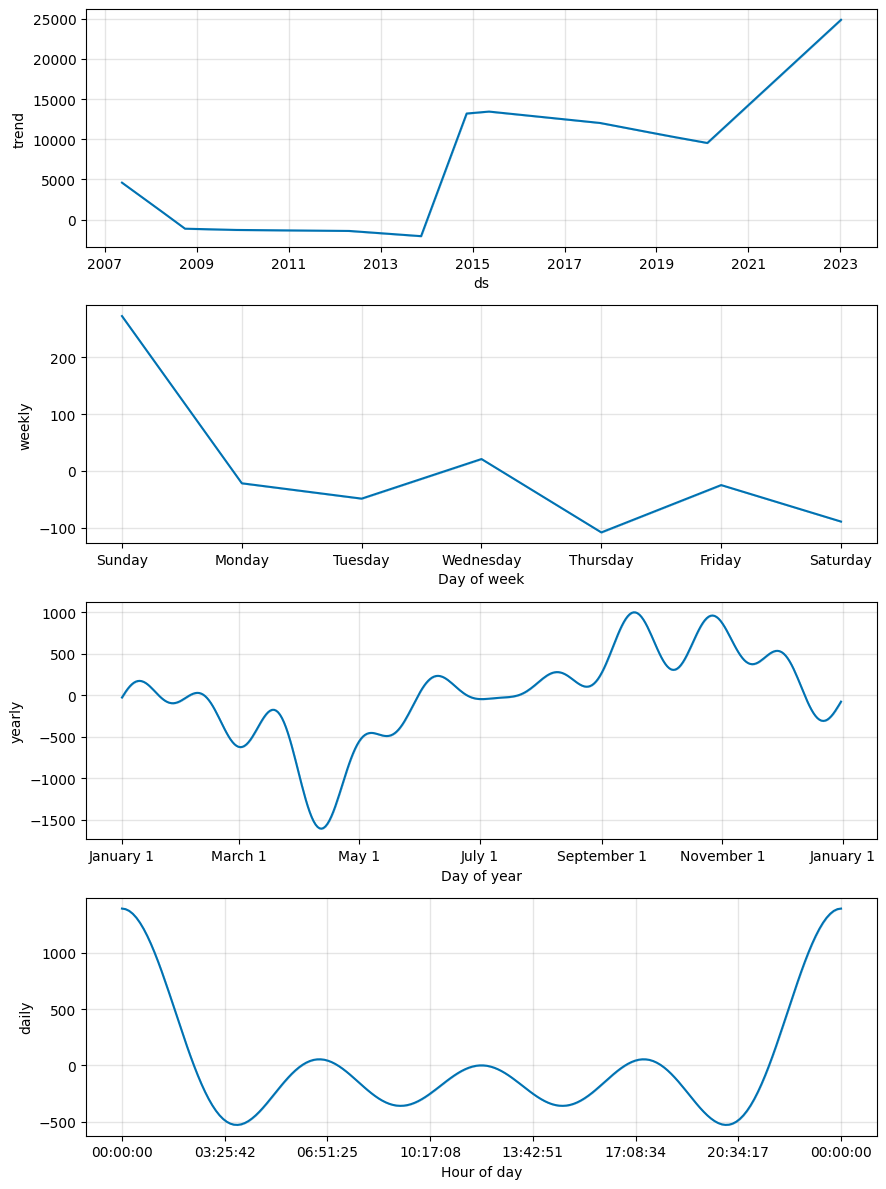

In [25]:
model.plot(forecast)
model.plot_components(forecast)


In [ ]:
next_day_price = forecast.iloc[-1]
print("Predicted Price:", round(next_day_price["yhat"], 2))


Predicted Price: 26294.01


In [36]:
# Next 7 predicted days (future only)
future_7 = forecast[forecast["ds"] > df_prophet["ds"].max()].head(7)


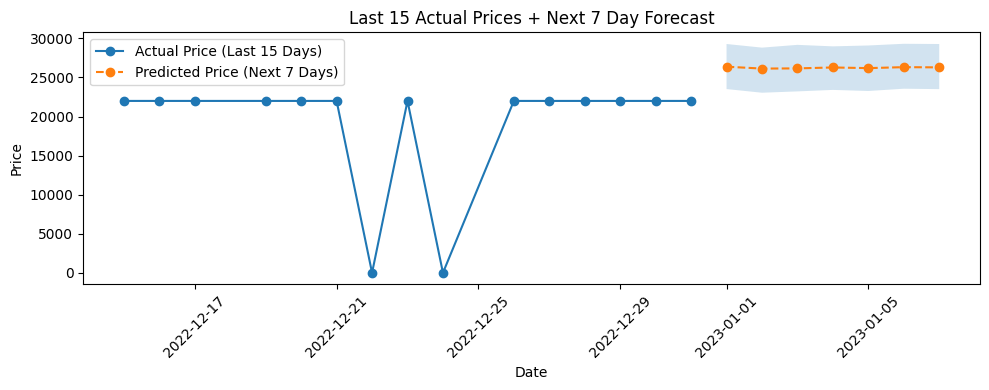

In [39]:
# Last 15 actual days
last_15_actual = df_prophet.tail(15)
plt.figure(figsize=(10,4))

# Plot actual prices
plt.plot(
    last_15_actual["ds"],
    last_15_actual["y"],
    marker='o',
    label="Actual Price (Last 15 Days)"
)

# Plot predicted prices
plt.plot(
    future_7["ds"],
    future_7["yhat"],
    marker='o',
    linestyle='--',
    label="Predicted Price (Next 7 Days)"
)

# Confidence interval
plt.fill_between(
    future_7["ds"],
    future_7["yhat_lower"],
    future_7["yhat_upper"],
    alpha=0.2
)

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Last 15 Actual Prices + Next 7 Day Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()